# Stratified cold storage

A chilled-water thermal store has no membrane. Cold water sits at the bottom because
it is denser, warm return water floats on top, and the only thing separating them is a
**thermocline** a fraction of a metre thick.

That matters because a district does not want kilowatt-hours, it wants *cold water at a
temperature*. As a tank cycles its thermocline thickens, by conduction and by the
mixing every inflow causes, so the water leaving the cold port creeps upward in
temperature long before the tank is empty. A store modelled as a single number cannot
express that, and a plant sized on one will be short of capacity exactly when it matters.

DisCoolPy's `StratifiedTank` resolves the tank into layers, in the same 1-D multinode
form used by mosaik-heatpump's hot water tank, inverted for district cooling: charging
pushes cold water in at the **bottom** and displaces warm water out of the **top**.

This notebook covers:

1. The tank on its own: geometry, capacity, and what a profile looks like
2. Charging and discharging, and watching the thermocline move
3. **The point:** the outlet temperature degrades, and a worn tank is worse than a fresh one
4. Standing losses
5. The tank in a real network, coupled hydraulically
6. What stratification changes against a scalar store of the same size
7. How to configure one

In [1]:
import copy
import logging
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from discoolpy import (
    ColdStorage,
    StratifiedTank,
    build_system,
    load_yaml_config,
    make_weather_and_load_profiles,
    run_configured_case,
)

warnings.filterwarnings('ignore', category=FutureWarning)
# TESPy logs every part-load excursion outside a compressor characteristic's range.
# It extrapolates correctly; the notice is just noise here.
logging.getLogger('TESPyLogger').setLevel(logging.ERROR)
pd.set_option('display.width', 130)

BLUE, ORANGE, INK = '#2a78d6', '#eb6834', '#52514e'

## 1. The tank on its own

A tank is defined by its geometry and by the two temperatures it works between: the
**charged** temperature (what the plant supplies) and the **discharged** temperature
(what the district returns). Those two set the capacity; it is not a free parameter:

$$E_{\\mathrm{capacity}} = m \\cdot c_p \\cdot (T_{\\mathrm{discharged}} - T_{\\mathrm{charged}})$$

This is already a difference from a scalar store, where you type a capacity in kWh and a
volume separately and nothing checks that they agree.

In [2]:
tank = StratifiedTank(
    volume_m3=600.0,
    height_to_diameter=2.5,      # tall and slender stratifies better
    layers=14,
    charged_temperature_degC=5.0,
    discharged_temperature_degC=13.0,
    initial_soc=1.0,
)
pd.Series(tank.describe()).round(2)

volume_m3                       600.00
height_m                         16.84
diameter_m                        6.74
layers                           14.00
layer_height_m                    1.20
capacity_kWh                   5567.76
charged_temperature_degC          5.00
discharged_temperature_degC      13.00
shell_UA_W_K                    119.72
dtype: float64

`initial_soc` places a **sharp** thermocline at the corresponding height, not a uniform
lukewarm temperature. That is the honest starting point: a tank at 50 % has half its
height cold and half warm, and the two states behave completely differently on the next
discharge.

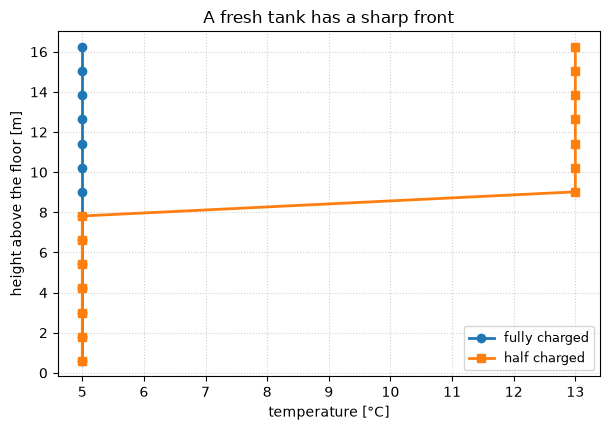

In [3]:
def plot_profiles(named_tanks, title):
    fig, ax = plt.subplots(figsize=(6.2, 4.4))
    for label, t, style in named_tanks:
        p = pd.DataFrame(t.profile())
        ax.plot(p['temperature_degC'], p['height_m'], style, label=label, lw=2)
    ax.set_xlabel('temperature [°C]')
    ax.set_ylabel('height above the floor [m]')
    ax.set_title(title)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(fontsize=9)
    fig.tight_layout()
    plt.show()

half = StratifiedTank(volume_m3=600.0, height_to_diameter=2.5, layers=14,
                      charged_temperature_degC=5.0, discharged_temperature_degC=13.0,
                      initial_soc=0.5)
plot_profiles([('fully charged', tank, '-o'), ('half charged', half, '-s')],
              'A fresh tank has a sharp front')

## 2. Charging and discharging

Each step takes a duration, a mass flow, an inlet temperature and a mode. Charging sends
cold water into the bottom; discharging sends warm return water into the top. Watch the
front travel.

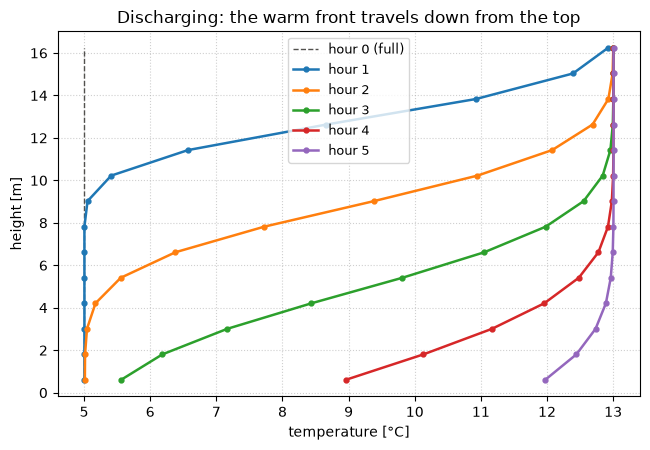

In [4]:
def snapshots_of(t, hours_list, flow, inlet, mode, env=35.0):
    """Step the tank hour by hour, keeping the profile at chosen hours."""
    kept, results = {}, []
    for hour in range(1, max(hours_list) + 1):
        results.append(t.step(1.0, flow, inlet, mode, env))
        if hour in hours_list:
            kept[hour] = list(t.temperatures_degC)
    return kept, results

drain = StratifiedTank(volume_m3=600.0, height_to_diameter=2.5, layers=14,
                       charged_temperature_degC=5.0, discharged_temperature_degC=13.0,
                       initial_soc=1.0)
kept, results = snapshots_of(drain, [1, 2, 3, 4, 5], 40.0, 13.0, 'discharge')

heights = [(i + 0.5) * drain.layer_height_m for i in range(drain.layers)]
fig, ax = plt.subplots(figsize=(6.6, 4.6))
ax.plot([5.0] * len(heights), heights, '--', color=INK, lw=1, label='hour 0 (full)')
for hour, profile in kept.items():
    ax.plot(profile, heights, '-o', ms=3.5, lw=1.8, label=f'hour {hour}')
ax.set_xlabel('temperature [°C]')
ax.set_ylabel('height [m]')
ax.set_title('Discharging: the warm front travels down from the top')
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

## 3. The point: the outlet degrades

This is what a scalar store cannot say. Below, the tank's state of charge falls smoothly,
but the **temperature it delivers** holds flat and then breaks upward once the thermocline
reaches the bottom port. Delivered power collapses with it.

In [5]:
table = pd.DataFrame({
    'hour': range(1, len(results) + 1),
    'soc': [r.soc_after for r in results],
    'outlet_degC': [r.outlet_temperature_degC for r in results],
    'delivered_kW': [r.discharge_power_W / 1e3 for r in results],
    'thermocline_m': [r.thermocline_thickness_m for r in results],
})
table.round(3)

,hour,soc,outlet_degC,delivered_kW,thermocline_m
0,1,0.759,5.002,1337.253,2.778
1,2,0.519,5.007,1336.352,3.894
2,3,0.281,5.102,1320.613,4.752
3,4,0.095,6.820,1033.342,3.361
4,5,0.018,10.445,427.166,0.000


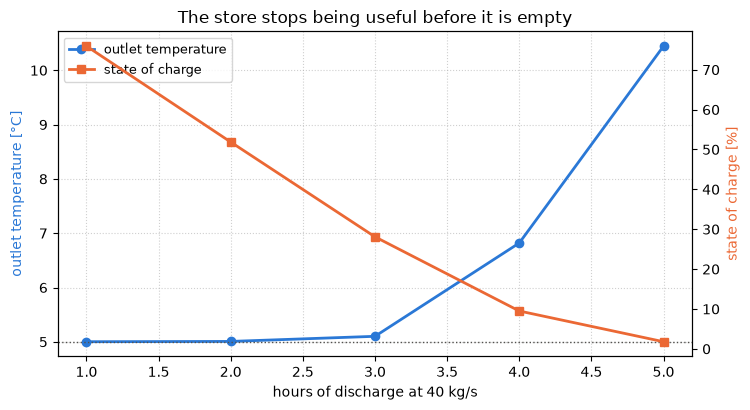

In [6]:
fig, ax = plt.subplots(figsize=(7.6, 4.2))
ax.plot(table['hour'], table['outlet_degC'], '-o', color=BLUE, lw=2,
        label='outlet temperature')
ax.axhline(5.0, color=INK, ls=':', lw=1)
ax.set_ylabel('outlet temperature [°C]', color=BLUE)
ax.set_xlabel('hours of discharge at 40 kg/s')
ax.grid(True, linestyle=':', alpha=0.6)

twin = ax.twinx()
twin.plot(table['hour'], table['soc'] * 100, '-s', color=ORANGE, lw=2, label='state of charge')
twin.set_ylabel('state of charge [%]', color=ORANGE)

ax.set_title('The store stops being useful before it is empty')
lines = ax.get_lines()[:1] + twin.get_lines()
ax.legend(lines, [l.get_label() for l in lines], fontsize=9, loc='upper left')
fig.tight_layout()
plt.show()

### A worn tank is worse than a fresh one holding the same energy

Stored kWh is not the same as *deliverable* kWh. Cycling blurs the front, so more of the
charge can only be handed over as lukewarm water. Measured as the share of stored cooling
deliverable below a temperature limit, the two tanks are not equivalent, and a scalar
store cannot tell them apart.

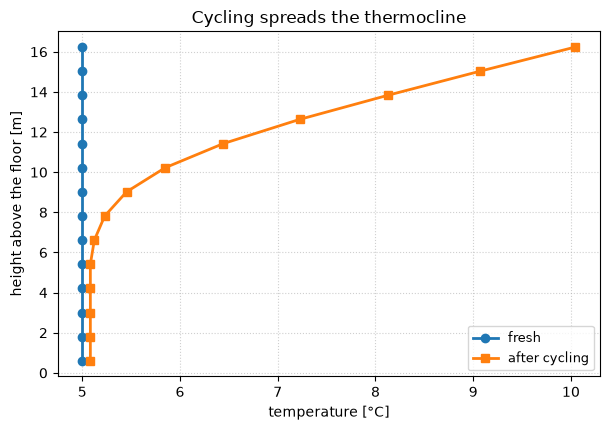

thermocline   fresh  0.00 m   worn  5.17 m
stored        fresh    5568 kWh  worn    4674 kWh
mean delivery temperature:  fresh 5.92 °C   worn 6.39 °C   (+0.47 K)


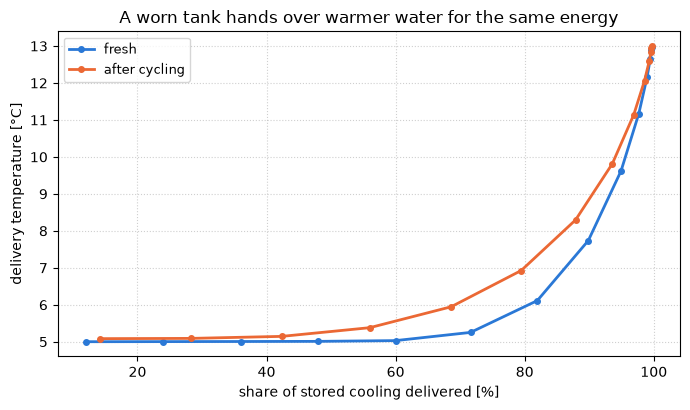

In [7]:
def make_tank(soc=1.0):
    return StratifiedTank(volume_m3=600.0, height_to_diameter=2.5, layers=14,
                          charged_temperature_degC=5.0, discharged_temperature_degC=13.0,
                          initial_soc=soc)

def delivery_curve(t):
    """Outlet temperature against the share of stored cooling delivered.

    The whole curve rather than a single threshold: where a cut-off falls
    between two layers is a discretisation detail, but the shape of the
    curve, and the energy-weighted mean under it, is not.
    """
    stored, cumulative, points = t.energy_kWh, 0.0, []
    weighted = total = 0.0
    for _ in range(40):
        r = t.step(0.5, 40.0, 13.0, 'discharge', 38.0)
        if r.discharge_power_W <= 0:
            break
        energy = r.discharge_power_W * 0.5 / 1e3
        cumulative += energy
        weighted += r.outlet_temperature_degC * energy
        total += energy
        points.append((cumulative / stored, r.outlet_temperature_degC))
    return points, weighted / total

fresh, worn = make_tank(), make_tank()
for _ in range(3):                       # partial cycles blur the front
    for _ in range(3): worn.step(1.0, 40.0, 13.0, 'discharge', 38.0)
    for _ in range(3): worn.step(1.0, 40.0, 5.0, 'charge', 38.0)
for _ in range(12): worn.step(1.0, 0.0, None, 'idle', 38.0)

plot_profiles([('fresh', fresh, '-o'), ('after cycling', worn, '-s')],
              'Cycling spreads the thermocline')

print(f'thermocline   fresh {fresh.thermocline_thickness_m():5.2f} m'
      f'   worn {worn.thermocline_thickness_m():5.2f} m')
print(f'stored        fresh {fresh.energy_kWh:7.0f} kWh  worn {worn.energy_kWh:7.0f} kWh')

fresh_pts, fresh_mean = delivery_curve(fresh)
worn_pts, worn_mean = delivery_curve(worn)
print(f'mean delivery temperature:  fresh {fresh_mean:.2f} °C'
      f'   worn {worn_mean:.2f} °C   ({worn_mean - fresh_mean:+.2f} K)')

fig, ax = plt.subplots(figsize=(7.0, 4.2))
for (pts, label, colour) in ((fresh_pts, 'fresh', BLUE), (worn_pts, 'after cycling', ORANGE)):
    ax.plot([x * 100 for x, _ in pts], [T for _, T in pts], '-o', ms=4, lw=2,
            color=colour, label=label)
ax.set_xlabel('share of stored cooling delivered [%]')
ax.set_ylabel('delivery temperature [°C]')
ax.set_title('A worn tank hands over warmer water for the same energy')
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

## 4. Standing losses

The tank computes its shell gain layer by layer, so a partly charged tank loses heat
wherever it is coldest and the loss follows the weather. There is no separate flat
percentage-per-day term, setting one alongside a stratified tank is refused, because it
would count the same loss twice.

shell UA 119.7 W/K
mean gain over 48 h idle at 40 °C: 4.17 kW
state of charge 0.999 -> 0.964
cold port drifted 5.01 -> 5.27 °C


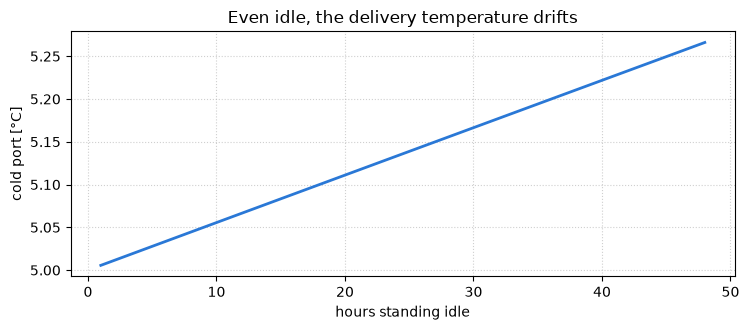

In [8]:
standing = make_tank()
gains, cold_port, socs = [], [], []
for _ in range(48):
    r = standing.step(1.0, 0.0, None, 'idle', 40.0)
    gains.append(r.ambient_heat_gain_W / 1e3)
    cold_port.append(standing.cold_port_temperature_degC)
    socs.append(standing.soc)

print(f"shell UA {standing.describe()['shell_UA_W_K']:.1f} W/K")
print(f'mean gain over 48 h idle at 40 °C: {np.mean(gains):.2f} kW')
print(f'state of charge {socs[0]:.3f} -> {socs[-1]:.3f}')
print(f'cold port drifted {cold_port[0]:.2f} -> {cold_port[-1]:.2f} °C')

fig, ax = plt.subplots(figsize=(7.6, 3.4))
ax.plot(range(1, 49), cold_port, color=BLUE, lw=2)
ax.set_xlabel('hours standing idle')
ax.set_ylabel('cold port [°C]')
ax.set_title('Even idle, the delivery temperature drifts')
ax.grid(True, linestyle=':', alpha=0.6)
fig.tight_layout()
plt.show()

## 5. In a real network

`configs/config_campus_five_buildings.yaml` carries a stratified tank, coupled
**hydraulically**: a real heat exchanger in the plant section of the chilled-water loop,
carrying `Q = charge − discharge`.

The tank's ports see the network's actual water, so its inlet conditions come from the
solved supply and return temperatures (using the previous snapshot as a one-step
predictor, seeded from the design solve).

One rule matters here: **the tank's temperatures must match what the network circulates.**
It cannot charge colder than the plant supplies, nor discharge warmer than the district
returns. DisCoolPy warns if you ask it to.

In [9]:
CONFIG = Path('..') / 'configs' / 'config_campus_five_buildings.yaml'
config = load_yaml_config(CONFIG)
config['profiles']['periods'] = 96          # two days at 30 min
config['outputs']['output_dir'] = '../outputs/stratified_notebook'

system = build_system(config)
store = system.storage
print('stratified:', store.is_stratified, '| coupling:', store.coupling)
print()
print(pd.Series(store.stratified.describe()).round(2).to_string())
print()
design = config['design']
print(f"network supplies {design['supply_temperature_degC']} °C, "
      f"buildings return {design['building_return_temperature_degC']} °C")

stratified:

 True | coupling: hydraulic

volume_m3                       425.00
height_m                         15.41
diameter_m                        5.93
layers                           14.00
layer_height_m                    1.10
capacity_kWh                   3204.36
charged_temperature_degC          7.00
discharged_temperature_degC      13.50
shell_UA_W_K                     75.25

network supplies 7.0 °C, buildings return 13.5 °C


In [10]:
system.network.solve(mode='design', max_iter=300)
assert system.network.converged

gains = system.branch.heat_gain_report()
buildings = sum(b.component.Q.val for b in system.buildings)
pump = system.branch.pump.P.val
residual = (system.chiller.solved_Q_evap_W - buildings
            - gains['total_heat_gain_W'] - pump)
print(f'plant duty       {system.chiller.solved_Q_evap_W/1e3:9.2f} kW')
print(f'buildings        {buildings/1e3:9.2f} kW')
print(f'pipe gain        {gains["total_heat_gain_W"]/1e3:9.2f} kW')
print(f'pump heat        {pump/1e3:9.2f} kW')
print(f'closure residual {residual:9.2e} W   (the store is idle at design)')

plant duty         1801.76 kW
buildings          1750.00 kW
pipe gain            24.29 kW
pump heat            27.47 kW
closure residual  5.26e-09 W   (the store is idle at design)


### Two days of operation

The store charges overnight and discharges into the afternoon peak. Because the tank is
resolved, we can watch the profile itself rather than a single number.

In [11]:
profile = make_weather_and_load_profiles(config)
results = run_configured_case(config, profile, 'stratified', use_storage=True,
                              progress=False)
print('max |closure residual|:', f"{results['chw_energy_residual_W'].abs().max():.2e} W")

cols = ['timestamp', 'storage_mode', 'storage_charge_power_W',
        'storage_discharge_power_W', 'storage_soc_after',
        'storage_cold_port_degC', 'storage_thermocline_m']
results[cols].iloc[::12].round(2)

max |closure residual|: 1.32e-08 W


,timestamp,storage_mode,storage_charge_power_W,storage_discharge_power_W,storage_soc_after,storage_cold_port_degC,storage_thermocline_m
0,2026-08-10T00:00:00,charge,160591.64,0.00,0.69,7.00,1.50
12,2026-08-10T06:00:00,charge,1548.32,0.00,0.95,7.02,1.62
24,2026-08-10T12:00:00,discharge,0.00,121639.53,0.90,7.04,2.62
36,2026-08-10T18:00:00,discharge,0.00,147668.38,0.54,7.09,4.82
48,2026-08-11T00:00:00,charge,118835.46,0.00,0.54,7.07,5.54
60,2026-08-11T06:00:00,charge,156383.57,0.00,0.94,7.00,1.92
72,2026-08-11T12:00:00,discharge,0.00,168205.74,0.87,7.03,3.19
84,2026-08-11T18:00:00,discharge,0.00,199325.03,0.41,7.40,5.54


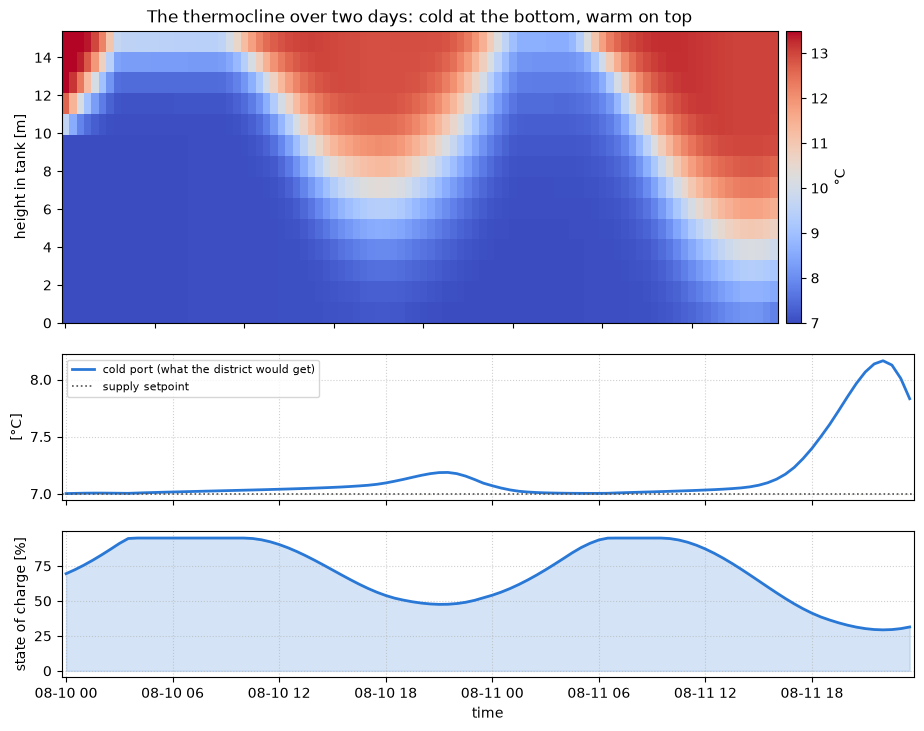

In [12]:
layer_cols = sorted(
    (c for c in results.columns if c.startswith('storage_tank_T')),
    key=lambda c: int(c.rsplit('T', 1)[1].split('_')[0]),
)
profile_grid = results[layer_cols].to_numpy().T      # layers x time, bottom first
index = pd.to_datetime(results['timestamp'])
tank_obj = store.stratified

fig, axes = plt.subplots(3, 1, figsize=(11, 8.4), sharex=True,
                         gridspec_kw={'height_ratios': [2.0, 1.0, 1.0], 'hspace': 0.16})

mesh = axes[0].pcolormesh(index, [(i + 0.5) * tank_obj.layer_height_m
                                  for i in range(tank_obj.layers)],
                          profile_grid, cmap='coolwarm', shading='nearest',
                          vmin=tank_obj.charged_temperature_degC,
                          vmax=tank_obj.discharged_temperature_degC)
axes[0].set_ylabel('height in tank [m]')
axes[0].set_title('The thermocline over two days: cold at the bottom, warm on top')
fig.colorbar(mesh, ax=axes[0], pad=0.01, label='°C')

axes[1].plot(index, results['storage_cold_port_degC'], color=BLUE, lw=2,
             label='cold port (what the district would get)')
axes[1].axhline(design['supply_temperature_degC'], color=INK, ls=':', lw=1.2,
                label='supply setpoint')
axes[1].set_ylabel('[°C]')
axes[1].legend(fontsize=8, loc='upper left')
axes[1].grid(True, linestyle=':', alpha=0.6)

axes[2].fill_between(index, 0, results['storage_soc_after'] * 100,
                     color=BLUE, alpha=0.20)
axes[2].plot(index, results['storage_soc_after'] * 100, color=BLUE, lw=2)
axes[2].set_ylabel('state of charge [%]')
axes[2].set_xlabel('time')
axes[2].grid(True, linestyle=':', alpha=0.6)

fig.tight_layout()
plt.show()

The top panel is the thing worth staring at. The blue cold zone grows upward overnight as
the tank charges, then is eaten from the top down through the afternoon. Notice that the
boundary is a band rather than a line, and the band gets wider each cycle. That is the
capacity quietly being lost.

In [13]:
discharging = results[results['storage_discharge_power_W'] > 1e3]
outlet = discharging['storage_tank_outlet_temperature_degC'].dropna()
energy = discharging['storage_discharge_power_W'] * discharging['resolution_hours']
setpoint = design['supply_temperature_degC']
within = outlet.index[outlet <= setpoint + 0.5]

print(f'delivered                : {energy.sum()/1e3:8.1f} kWh')
print(f'within 0.5 K of setpoint : {energy.loc[within].sum()/1e3:8.1f} kWh '
      f'({energy.loc[within].sum()/energy.sum():.1%})')
print(f'outlet range             : {outlet.min():.2f} to {outlet.max():.2f} °C')
print(f'thermocline              : {results["storage_thermocline_m"].min():.2f} to '
      f'{results["storage_thermocline_m"].max():.2f} m of {tank_obj.height_m:.1f} m')

delivered                :   3570.1 kWh
within 0.5 K of setpoint :   3282.2 kWh (91.9%)
outlet range             : 7.02 to 8.14 °C
thermocline              : 1.19 to 6.41 m of 15.4 m


## 6. What stratification changes

The honest comparison is the same scenario, same capacity, same coupling, modelled as a
scalar reservoir instead. Turning the `stratified` block off falls back to exactly that.

In [14]:
scalar_config = copy.deepcopy(config)
s = scalar_config['storage']
s['stratified'] = {'enabled': False}
s['capacity_kWh'] = float(store.stratified.capacity_kWh)   # match it exactly
s['loss_model'] = 'ua'
s['thermal'] = {
    'UA_W_K': float(store.stratified.describe()['shell_UA_W_K']),
    'storage_temperature_degC': store.stratified.charged_temperature_degC,
    'discharged_temperature_degC': store.stratified.discharged_temperature_degC,
    'temperature_varies_with_soc': True,
}
s['charge_efficiency'] = s['discharge_efficiency'] = 1.0   # the tank has no typed-in eta

scalar = run_configured_case(scalar_config, profile, 'scalar', use_storage=True,
                             progress=False)
hours_step = float(results['resolution_hours'].iloc[0])

comparison = pd.DataFrame({
    'scalar store': {
        'peak compressor power [kW]': scalar['compressor_power_W'].max() / 1e3,
        'compressor energy [kWh]': scalar['compressor_power_W'].sum() * hours_step / 1e3,
        'cooling discharged [kWh]': scalar['storage_discharge_power_W'].sum() * hours_step / 1e3,
        'min state of charge': scalar['storage_soc_after'].min(),
    },
    'stratified tank': {
        'peak compressor power [kW]': results['compressor_power_W'].max() / 1e3,
        'compressor energy [kWh]': results['compressor_power_W'].sum() * hours_step / 1e3,
        'cooling discharged [kWh]': results['storage_discharge_power_W'].sum() * hours_step / 1e3,
        'min state of charge': results['storage_soc_after'].min(),
    },
})
comparison['difference %'] = (comparison['stratified tank'] / comparison['scalar store'] - 1) * 100
comparison.round(2)

,scalar store,stratified tank,difference %
peak compressor power [kW],380.11,377.99,-0.56
compressor energy [kWh],17286.74,17285.32,-0.01
cooling discharged [kWh],3571.41,3570.07,-0.04
min state of charge,0.29,0.29,0.04


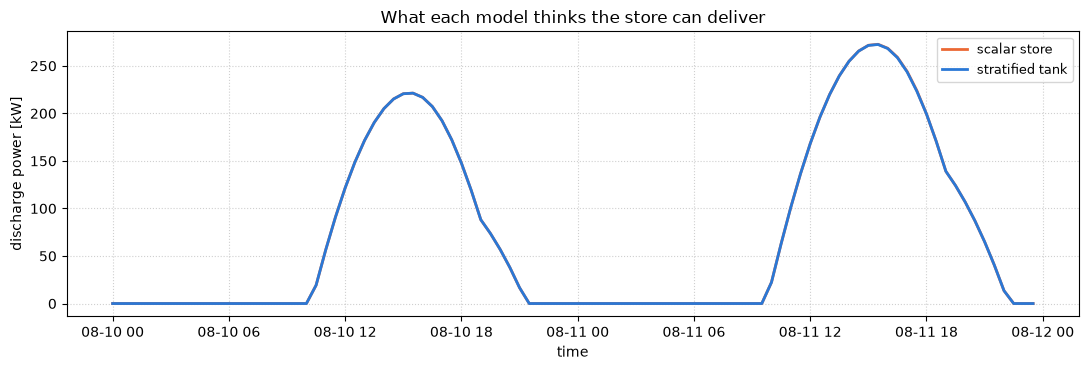

In [15]:
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(index, scalar['storage_discharge_power_W'] / 1e3, color=ORANGE, lw=2,
        label='scalar store')
ax.plot(index, results['storage_discharge_power_W'] / 1e3, color=BLUE, lw=2,
        label='stratified tank')
ax.set_ylabel('discharge power [kW]')
ax.set_xlabel('time')
ax.set_title('What each model thinks the store can deliver')
ax.legend(fontsize=9)
ax.grid(True, linestyle=':', alpha=0.6)
fig.tight_layout()
plt.show()

Over this horizon the two agree closely, and that is a legitimate result rather than a
failure of the stratified model: the store is never driven below about 30 % state of
charge, so its thermocline never reaches the outlet and the scalar assumption happens to
hold.

**The difference appears when the store is pushed.** Below, the load-levelling target is
lowered so the tank is drained hard.

In [16]:
stress = copy.deepcopy(config)
stress['storage']['target_chiller_load_kW'] = 1300.0     # ask much more of the store
stressed = run_configured_case(stress, profile, 'stressed', use_storage=True,
                               progress=False)

stress_scalar = copy.deepcopy(scalar_config)
stress_scalar['storage']['target_chiller_load_kW'] = 1300.0
stressed_scalar = run_configured_case(stress_scalar, profile, 'stressed_scalar',
                                      use_storage=True, progress=False)

print(f"minimum state of charge   stratified {stressed['storage_soc_after'].min():.3f}"
      f"   scalar {stressed_scalar['storage_soc_after'].min():.3f}")
print(f"cold port reached         {stressed['storage_cold_port_degC'].max():.2f} °C"
      f"   (return temperature is {design['building_return_temperature_degC']} °C)")

minimum state of charge   stratified 0.067   scalar 0.050
cold port reached         13.01 °C   (return temperature is 13.5 °C)


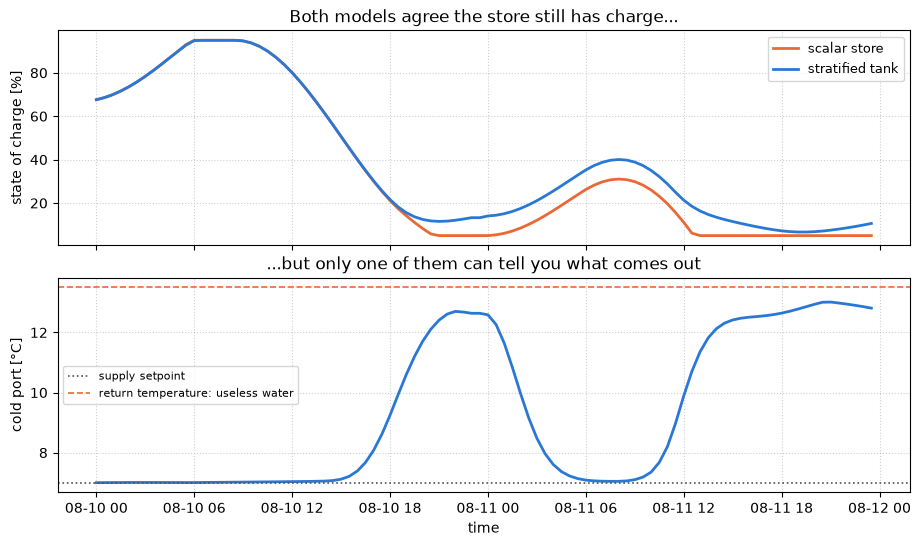

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6.0), sharex=True,
                         gridspec_kw={'height_ratios': [1, 1], 'hspace': 0.15})

axes[0].plot(index, stressed_scalar['storage_soc_after'] * 100, color=ORANGE, lw=2,
             label='scalar store')
axes[0].plot(index, stressed['storage_soc_after'] * 100, color=BLUE, lw=2,
             label='stratified tank')
axes[0].set_ylabel('state of charge [%]')
axes[0].set_title('Both models agree the store still has charge...')
axes[0].legend(fontsize=9)
axes[0].grid(True, linestyle=':', alpha=0.6)

axes[1].plot(index, stressed['storage_cold_port_degC'], color=BLUE, lw=2)
axes[1].axhline(design['supply_temperature_degC'], color=INK, ls=':', lw=1.2,
                label='supply setpoint')
axes[1].axhline(design['building_return_temperature_degC'], color=ORANGE, ls='--',
                lw=1.2, label='return temperature: useless water')
axes[1].set_ylabel('cold port [°C]')
axes[1].set_xlabel('time')
axes[1].set_title('...but only one of them can tell you what comes out')
axes[1].legend(fontsize=8)
axes[1].grid(True, linestyle=':', alpha=0.6)

fig.tight_layout()
plt.show()

There it is. Driven hard, the tank's cold port climbs all the way to the district's
**return** temperature, at which point the store is circulating water that does no
cooling at all, even though its state of charge still reads a few per cent. The scalar
model has no such curve to draw: it has an amount, not a temperature, so it reports the
store as merely low rather than useless.

That is the whole case for resolving the tank. Not that the numbers always move, but that
you can see **when the simpler model would have misled you**, and you get the delivery
temperature, which is what a district actually contracts on.

## 7. Configuring one

```yaml
storage:
  enabled: true
  label: chilled_water_store
  storage_type: chilled_water
  initial_soc: 0.67
  max_charge_kW: 420.0
  max_discharge_kW: 420.0
  coupling: hydraulic          # a stratified tank wants to be in the loop
  loss_model: ua               # the tank owns its shell loss, layer by layer

  stratified:
    enabled: true
    volume_m3: 425.0
    layers: 14                 # ~1 m per layer
    height_to_diameter: 2.6    # tall and slender stratifies better
    charged_temperature_degC: 7.0     # == the plant's supply setpoint
    discharged_temperature_degC: 13.5 # == the district's return
    wall_htc_W_m2K: 0.22

  max_tank_flow_kg_s: 15.5     # what the diffusers can pass
  target_chiller_load_kW: 1420.0
  min_soc: 0.05
  max_soc: 0.95
```

Four rules cover almost everything that goes wrong:

1. **Match the temperatures to the network.** `charged_temperature_degC` is the plant's
   supply setpoint and `discharged_temperature_degC` is the district's return. A tank
   asked to charge colder than the plant supplies simply goes isothermal and stops
   working; DisCoolPy warns when it spots this.
2. **Capacity is not an input.** Volume and the temperature span determine it. If you want
   a particular capacity, size the volume: `V = E·3.6e6 / (ρ·c_p·ΔT)`.
3. **Do not set an efficiency or a flat standby loss.** Both are emergent here: the
   round trip comes out of mixing and shell gain. `loss_model: fraction` alongside a
   stratified tank is refused rather than silently double-counted.
4. **Use enough layers.** Twelve to sixteen is a good range. Below about six the
   thermocline is wider than the discretisation can represent, and the model will
   understate the usable capacity.

See [docs/cold_storage.md](../docs/cold_storage.md) for the full reference.